# Titanic Dataset — Student Worksheet (Evaluation)

**Total: 100 points**  
You will implement: data loading, filtering, survival-rate computations, histogram, missing-value imputation, matrix construction, logistic regression evaluation (**ROC + confusion matrix**), and **feature weight inspection**.

## Rules / constraints
- Use **pandas only when strictly necessary** (load CSV, select/filter rows, basic inspection).
- For feature matrices and most computations, prefer **NumPy**.
- **No scikit-learn Pipelines.**
- Use the **exact variable names** requested (checked by the correction cell).

## Required variable names (must exist)
- `df` : raw DataFrame loaded from file
- `df_imp` : DataFrame after imputations (embarked, fare, age)
- `Xa` : NumPy matrix with columns `[sex, age, sibsp, parch, fare, embarked_num]` where `embarked_num` is encoded as C/Q/S → 0/1/2
- `Xb` : NumPy matrix with columns `[sex, age, sibsp, parch, fare, emb_Q, emb_S]` where C is baseline (both 0)
- `y` : NumPy vector target (`survived`)
- `random_state` : integer random seed (**must be `42`**)
- `model_Xa`, `model_Xb` : trained LogisticRegression models
- `auc_Xa`, `auc_Xb` : ROC AUC values on test split

## Files
Place `titanic.csv` in the **same folder** as this notebook.

---

In [1]:
# Imports (do not change unless necessary)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


## Part A — Load data (10 pts)

Load `titanic.csv` into a DataFrame named **`df`**.

**Important:** In some versions, the file is **tab-separated** and uses **decimal comma** for floats.  
Try:
- `pd.read_csv('titanic.csv', sep='\t', decimal=',')`
If that fails (or produces wrong columns), try:
- `pd.read_csv('titanic.csv')`


In [3]:
# TODO (A1): Load the dataset into df
df = pd.read_csv("titanic.csv", sep="\t", decimal=",")  # <-- replace

# Sanity checks (do not remove)
print("df type:", type(df))
print("df shape:", None if df is None else df.shape)
print("has survived:", False if df is None else ("survived" in df.columns))


df type: <class 'pandas.DataFrame'>
df shape: (1309, 14)
has survived: True


## Part B — Visualize passengers from Spain (10 pts)

Use only **`home.dest`** to find passengers with a destination/home containing **"spain"** (case-insensitive).

Create:
- `df_spain` : DataFrame with those passengers
- Display at least: `name`, `home.dest`, `pclass`, `fare`, `survived`


In [7]:
# TODO (B1): create df_spain and display requested columns
df_spain = df[df["home.dest"].str.contains("spain", case=False, na=False)]   # case ignora o CAPS, na ignora os vazius

# Example display (replace with your own)
print(df_spain[["name", "home.dest", "pclass", "fare", "survived"]])


                                                  name  \
228         Penasco y Castellana, Mr. Victor de Satode   
229  Penasco y Castellana, Mrs. Victor de Satode (M...   
401                       Duran y More, Miss. Asuncion   
402                     Duran y More, Miss. Florentina   
524                         Padro y Manent, Mr. Julian   
526                      Pallas y Castello, Mr. Emilio   
546                          Reynaldo, Ms. Encarnacion   

                           home.dest  pclass      fare  survived  
228                    Madrid, Spain       1  108.9000         0  
229                    Madrid, Spain       1  108.9000         1  
401  Barcelona, Spain / Havana, Cuba       2   13.8583         1  
402  Barcelona, Spain / Havana, Cuba       2   13.8583         1  
524             Spain / Havana, Cuba       2   13.8625         1  
526             Spain / Havana, Cuba       2   13.8583         1  
546                            Spain       2   13.0000         1  

## Part C — Survival rates (15 pts)

Compute (floats in [0,1]):
- `rate_female` : survival rate among females
- `rate_male` : survival rate among males
- `rate_class1` : survival rate among 1st class (`pclass == 1`)

Prefer NumPy boolean masks.


In [8]:
# TODO (C1): compute survival rates
rate_female = df[df["sex"] == "female"]["survived"].mean()
rate_male = df[df["sex"] == "male"]["survived"].mean()
rate_class1 = df[df["pclass"] == 1]["survived"].mean()

print("rate_female:", rate_female)
print("rate_male  :", rate_male)
print("rate_class1:", rate_class1)


rate_female: 0.7274678111587983
rate_male  : 0.19098457888493475
rate_class1: 0.6191950464396285


## Part D — Histogram (10 pts)

Histogram comparing Age distributions for:
- Survived (`survived==1`)
- Died (`survived==0`)

Requirements:
- Same figure, `plt.hist`
- legend + title
- save as `fig_age_hist.png`


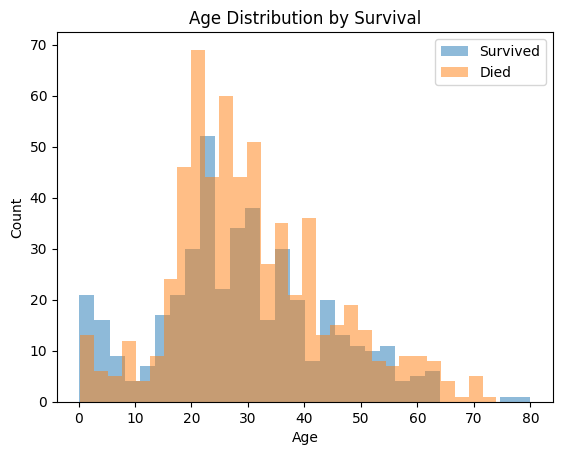

In [16]:
# TODO (D1): histogram of age by survival
# Save: fig_age_hist.png
age_survived = df[df["survived"] == 1]["age"].dropna()
age_died = df[df["survived"] == 0]["age"].dropna()

plt.figure()
plt.hist(age_survived, bins=30, alpha=0.5, label="Survived")
plt.hist(age_died, bins=30, alpha=0.5, label="Died")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution by Survival")
plt.legend()
plt.savefig("fig_age_hist.png")
plt.show()


## Part E — Simple imputations (25 pts)

Create **`df_imp`** (copy of `df`) and perform:

1) **embarked**: missing -> `"C"`  
2) **fare**: missing -> median fare of `pclass==3`  
3) **age**: group-wise median by (`sex`, `pclass`) using `transform("median")`

Afterwards, print missing counts for `embarked`, `fare`, `age`.


In [ ]:
# TODO (E1): imputations into df_imp
df_imp = df.copy()
df_imp["embarked"] = df_imp["embarked"].fillna("C")
df_imp["fare"] = df_imp["fare"].fillna(df_imp[df_imp["pclass"] == 3]["fare"].median())
df_imp["age"] = df_imp.groupby(["sex", "pclass"])["age"].transform("median")

# funcao [].fillna(valor) preenche os valores NA com o valor escolhido

# Verification (do not remove)
if df_imp is not None:
    print("Missing embarked:", df_imp["embarked"].isna().sum())
    print("Missing fare    :", df_imp["fare"].isna().sum())
    print("Missing age     :", df_imp["age"].isna().sum())

# [].isna().sum() verifica se é NA e soma 


Missing embarked: 0
Missing fare    : 0
Missing age     : 0


## Part F — Build `Xa` (15 pts)

Build **`Xa`** with exact columns:

`[sex, age, sibsp, parch, fare, embarked_num]`

Encoding:
- `sex`: male=0, female=1
- `embarked_num`: C→0, Q→1, S→2  (integer encoding)

Use `df_imp`. Also create:
- `y = df_imp["survived"].to_numpy()`


In [14]:
# TODO (F1): construct Xa and y from df_imp
sex_num = (df_imp["sex"] == "female").astype(int).to_numpy() # female = 1, male = 0
embarked_num = df_imp["embarked"].map({"C": 0, "Q": 1, "S": 2}).astype(int).to_numpy()

Xa = np.column_stack([
    sex_num,
    df_imp["age"].to_numpy(),
    df_imp["sibsp"].to_numpy(),
    df_imp["parch"].to_numpy(),
    df_imp["fare"].to_numpy(),
    embarked_num
])
y = df_imp["survived"].to_numpy()  # <-- replace

print("Xa shape:", None if Xa is None else Xa.shape)
print("y  shape:", None if y is None else y.shape)


Xa shape: (1309, 6)
y  shape: (1309,)


## Part G — Build `Xb` (10 pts)

Build **`Xb`** with exact columns:

`[sex, age, sibsp, parch, fare, emb_Q, emb_S]`

Where:
- `emb_Q` = 1 if embarked == "Q" else 0
- `emb_S` = 1 if embarked == "S" else 0  
(C is baseline when both are 0)


In [15]:
# TODO (G1): construct Xb from df_imp
emb_Q = (df_imp["embarked"] == "Q").astype(int).to_numpy()
emb_S = (df_imp["embarked"] == "S").astype(int).to_numpy()

Xb = np.column_stack([
    sex_num,
    df_imp["age"].to_numpy(),
    df_imp["sibsp"].to_numpy(),
    df_imp["parch"].to_numpy(),
    df_imp["fare"].to_numpy(),
    emb_Q,
    emb_S
])

print("Xb shape:", None if Xb is None else Xb.shape)


Xb shape: (1309, 7)


## Part H — Logistic regression + ROC + confusion matrix (15 pts)

Use the **same model settings** for both feature sets.

Requirements:
- Set `random_state = 42`
- `train_test_split(..., test_size=0.2, random_state=random_state, stratify=y)`
- Model: `LogisticRegression(max_iter=2000)`
- Train:
  - `model_Xa` on `Xa`
  - `model_Xb` on `Xb`
- Compute predicted probabilities on test and ROC AUC:
  - `auc_Xa`, `auc_Xb`
- Plot both ROC curves on **same figure** and save as `fig_roc_compare.png`
- Plot confusion matrix for **Xb** model and save as `fig_cm_Xb.png`

**Important note on scaling:**  
Logistic regression coefficients are easier to compare if you standardize numeric columns.  
You may standardize manually (mean/std from train only). No pipelines.


In [21]:
# TODO (H1): set the random seed (required name)
random_state = 42



auc_Xa: 0.8614506172839507
auc_Xb: 0.851141975308642


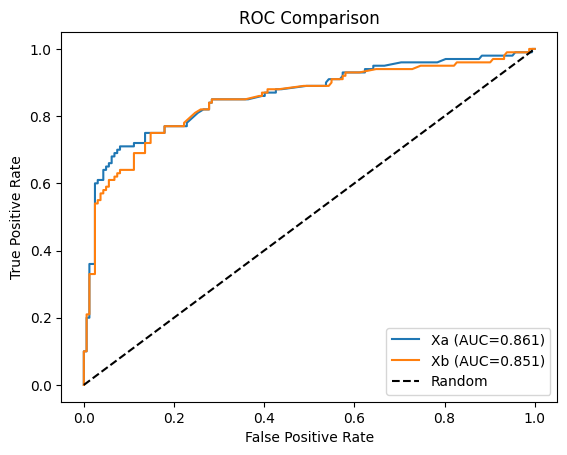

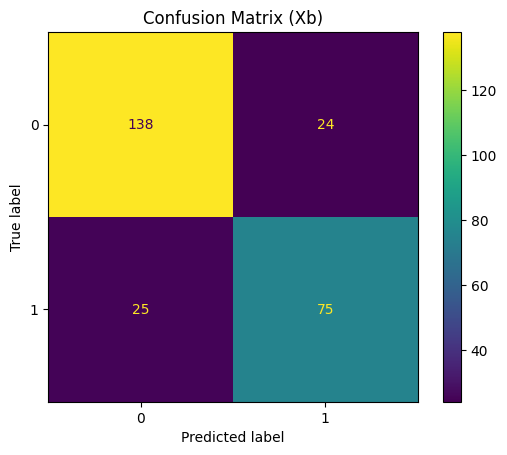

In [22]:
# TODO (H2): fit models and create requested plots

# Split (same split for both)
Xa_train, Xa_test, y_train, y_test = train_test_split(Xa, y, test_size=0.2, random_state=random_state, stratify=y)
Xb_train, Xb_test, y_train, y_test = train_test_split(Xb, y, test_size=0.2, random_state=random_state, stratify=y)

# Standardize manually (mean/std from train only)
Xa_mean, Xa_std = Xa_train.mean(axis=0), Xa_train.std(axis=0)
Xa_train_s = (Xa_train - Xa_mean) / Xa_std
Xa_test_s = (Xa_test - Xa_mean) / Xa_std

Xb_mean, Xb_std = Xb_train.mean(axis=0), Xb_train.std(axis=0)
Xb_train_s = (Xb_train - Xb_mean) / Xb_std
Xb_test_s = (Xb_test - Xb_mean) / Xb_std

# Train models
model_Xa = LogisticRegression(max_iter=2000)
model_Xa.fit(Xa_train_s, y_train)

model_Xb = LogisticRegression(max_iter=2000)
model_Xb.fit(Xb_train_s, y_train)

# Predicted probabilities and AUC
probs_Xa = model_Xa.predict_proba(Xa_test_s)[:, 1]
probs_Xb = model_Xb.predict_proba(Xb_test_s)[:, 1]
auc_Xa = roc_auc_score(y_test, probs_Xa)
auc_Xb = roc_auc_score(y_test, probs_Xb)

print("auc_Xa:", auc_Xa)
print("auc_Xb:", auc_Xb)

# ROC curves (same figure)
fpr_a, tpr_a, _ = roc_curve(y_test, probs_Xa)
fpr_b, tpr_b, _ = roc_curve(y_test, probs_Xb)

plt.figure()
plt.plot(fpr_a, tpr_a, label=f"Xa (AUC={auc_Xa:.3f})")
plt.plot(fpr_b, tpr_b, label=f"Xb (AUC={auc_Xb:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.savefig("fig_roc_compare.png")
plt.show()

# Confusion matrix for Xb
y_pred_Xb = model_Xb.predict(Xb_test_s)
cm = confusion_matrix(y_test, y_pred_Xb)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix (Xb)")
plt.savefig("fig_cm_Xb.png")
plt.show()


## Part I — Model weights: most discriminant features (15 pts)

Print the **top 6 most discriminant features** for each model (`Xa` and `Xb`) using:
- absolute value of logistic regression coefficients: `abs(coef)`

Create:
- `feat_names_Xa` : list of feature names in the same order as Xa columns
- `feat_names_Xb` : list of feature names in the same order as Xb columns

Then print top features (name + coefficient).


In [25]:
# TODO (I1): define feature name lists (required variables)
feat_names_Xa = ["sex", "age", "sibsp", "parch", "fare", "embarked_num"]  # <-- replace
feat_names_Xb = ["sex", "age", "sibsp", "parch", "fare", "emb_Q", "emb_S"]  # <-- replace


In [26]:
# TODO (I2): show most discriminant features for Xa and Xb
print("=== Top 6 features (Xa) ===")
coefs_Xa = model_Xa.coef_[0]
idx_Xa = np.argsort(np.abs(coefs_Xa))[::-1]
for j in idx_Xa[:6]:
    print(feat_names_Xa[j], coefs_Xa[j])

print("\n=== Top 6 features (Xb) ===")
coefs_Xb = model_Xb.coef_[0]
idx_Xb = np.argsort(np.abs(coefs_Xb))[::-1]
for j in idx_Xb[:6]:
    print(feat_names_Xb[j], coefs_Xb[j])



=== Top 6 features (Xa) ===
sex 1.29318648708795
age 0.5423204132184701
embarked_num -0.23377835525763918
sibsp -0.22458954921379284
fare 0.08499423092063617
parch 0.036937100877523894

=== Top 6 features (Xb) ===
sex 1.3232272050561174
age 0.49552218498240974
emb_S -0.3173962799385677
emb_Q -0.3094210987585031
sibsp -0.24264919484477193
fare 0.08250442356948298


# Part J — Correction / Auto-scoring (100 pts total)

Run this cell at the end. It checks:
- required variables exist
- key results match a reference (within tolerances)
- required figures were saved
- missing answers give 0 points for that part

**Do not edit this cell.**


In [27]:
from grader_titanic import grade
grade(globals())